เป้าหมาย: ทำนายว่าลูกค้าแต่ละคนจะ redeem โปรไหนหรือเปล่า
output = Next-Best-Offer Table
ทำไมใช้ XGBoost (GradientBoosting)?
1. Handle class imbalance ได้ดี
2. Feature Importance interpret เชิง business ได้ชัด
3. ไม่ต้อง normalize features (ต่างจาก Ridge)

# Import & Load

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve
)
from sklearn.preprocessing import LabelEncoder
import warnings
import os

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (10, 5)
sns.set_style('whitegrid')

COLORS = ['#534AB7', '#0F6E56', '#BA7517', '#993C1D', '#888888']

os.makedirs('data/processed', exist_ok=True)
os.makedirs('data/raw', exist_ok=True)

os.makedirs('diagrams', exist_ok=True)

rfm   = pd.read_csv('data/processed/rfm_with_forecast.csv')
txn   = pd.read_csv('data/processed/transactions_with_segment.csv',
                     parse_dates=['transaction_date'])
promo = pd.read_csv('data/raw/promotion_master.csv',
                     parse_dates=['start_date', 'end_date'])

print("=" * 50)
print("  NOTEBOOK 04 — XGBoost Classifier")
print("=" * 50)
print(f"\n✅ โหลดข้อมูลสำเร็จ")
print(f"   rfm   : {rfm.shape}")
print(f"   txn   : {txn.shape}")
print(f"   promo : {promo.shape}")

  NOTEBOOK 04 — XGBoost Classifier

✅ โหลดข้อมูลสำเร็จ
   rfm   : (500, 7)
   txn   : (2900, 8)
   promo : (10, 6)


# 1. สร้าง Target Variable (redeem = 1/0)

In [12]:
print("\n" + "─" * 50)
print("  SECTION 1 — สร้าง Training Dataset")
print("─" * 50)

txn_with_promo = txn[txn['promotion_id'] != 'NONE'].copy()
rows = []

for _, p in promo.iterrows():
    pid = p['promotion_id']

    # ลูกค้าที่ redeem โปรนี้จริงๆ
    redeemers = set(
        txn_with_promo[
            (txn_with_promo['promotion_id'] == pid) &
            (txn_with_promo['transaction_date'] >= p['start_date']) &
            (txn_with_promo['transaction_date'] <= p['end_date'])
        ]['customer_id']
    )

    for _, cust in rfm.iterrows():
        rows.append({
            'customer_id'        : cust['customer_id'],
            'promotion_id'       : pid,
            'promo_type'         : p['promo_type'],
            'discount_value'     : p['discount_value'],
            'target_segment'     : p['target_segment'],
            'recency'            : cust['recency'],
            'frequency'          : cust['frequency'],
            'monetary'           : cust['monetary'],
            'segment'            : cust['segment'],
            'predicted_spend_30d': cust['predicted_spend_30d'],
            'needs_promotion'    : cust['needs_promotion'],
            'redeem'             : 1 if cust['customer_id'] in redeemers else 0,
        })

model_df = pd.DataFrame(rows)

print(f"\n✅ Training dataset: {model_df.shape}")
print(f"   Redeem rate   : {model_df['redeem'].mean()*100:.2f}%")
print(f"   Class balance — 0: {(model_df['redeem']==0).sum():,}"
      f" | 1: {(model_df['redeem']==1).sum():,}")



──────────────────────────────────────────────────
  SECTION 1 — สร้าง Training Dataset
──────────────────────────────────────────────────

✅ Training dataset: (5000, 12)
   Redeem rate   : 15.46%
   Class balance — 0: 4,227 | 1: 773


# 2. Feature Engineering

In [13]:
print("\n" + "─" * 50)
print("  SECTION 2 — Feature Engineering")
print("─" * 50)

le_seg   = LabelEncoder()
le_ptype = LabelEncoder()
le_tseg  = LabelEncoder()

model_df['segment_enc']        = le_seg.fit_transform(model_df['segment'])
model_df['promo_type_enc']     = le_ptype.fit_transform(model_df['promo_type'])
model_df['target_segment_enc'] = le_tseg.fit_transform(model_df['target_segment'])

# Feature สำคัญ: โปรนี้ตรงกับ segment ของลูกค้าไหม?
model_df['segment_match'] = (
    (model_df['target_segment'] == 'All') |
    (model_df['target_segment'] == model_df['segment'])
).astype(int)

FEATURES = [
    'recency', 'frequency', 'monetary',
    'predicted_spend_30d', 'needs_promotion',
    'discount_value', 'segment_enc',
    'promo_type_enc', 'target_segment_enc', 'segment_match'
]
TARGET = 'redeem'

X = model_df[FEATURES]
y = model_df[TARGET]

print(f"\nFeatures ({len(FEATURES)} ตัว):")
for f in FEATURES:
    print(f"  - {f}")
print(f"\nTarget : {TARGET}")
print(f"Shape  : X={X.shape}, y={y.shape}")


──────────────────────────────────────────────────
  SECTION 2 — Feature Engineering
──────────────────────────────────────────────────

Features (10 ตัว):
  - recency
  - frequency
  - monetary
  - predicted_spend_30d
  - needs_promotion
  - discount_value
  - segment_enc
  - promo_type_enc
  - target_segment_enc
  - segment_match

Target : redeem
Shape  : X=(5000, 10), y=(5000,)


# 3. Train GradientBoosting (≈ XGBoost)

In [14]:
print("\n" + "─" * 50)
print("  SECTION 3 — Train Model")
print("─" * 50)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = GradientBoostingClassifier(
    n_estimators=200,   # จำนวน trees
    learning_rate=0.05, # ขนาด step แต่ละรอบ
    max_depth=4,        # ความลึก tree
    subsample=0.8,      # สุ่มข้อมูล 80% ต่อ tree
    random_state=42
)
model.fit(X_train, y_train)

y_pred     = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:, 1]
auc         = roc_auc_score(y_test, y_pred_prob)

print(f"\n✅ Model Trained")
print(f"   Train samples : {len(X_train):,}")
print(f"   Test samples  : {len(X_test):,}")
print(f"   AUC-ROC       : {auc:.4f}  (1.0 = perfect)")



──────────────────────────────────────────────────
  SECTION 3 — Train Model
──────────────────────────────────────────────────

✅ Model Trained
   Train samples : 4,000
   Test samples  : 1,000
   AUC-ROC       : 0.9005  (1.0 = perfect)


# 4. Model Evaluation


──────────────────────────────────────────────────
  SECTION 4 — Model Evaluation
──────────────────────────────────────────────────

Classification Report:
               precision    recall  f1-score   support

No Redeem (0)       0.92      0.96      0.94       845
   Redeem (1)       0.71      0.53      0.61       155

     accuracy                           0.89      1000
    macro avg       0.82      0.74      0.77      1000
 weighted avg       0.89      0.89      0.89      1000



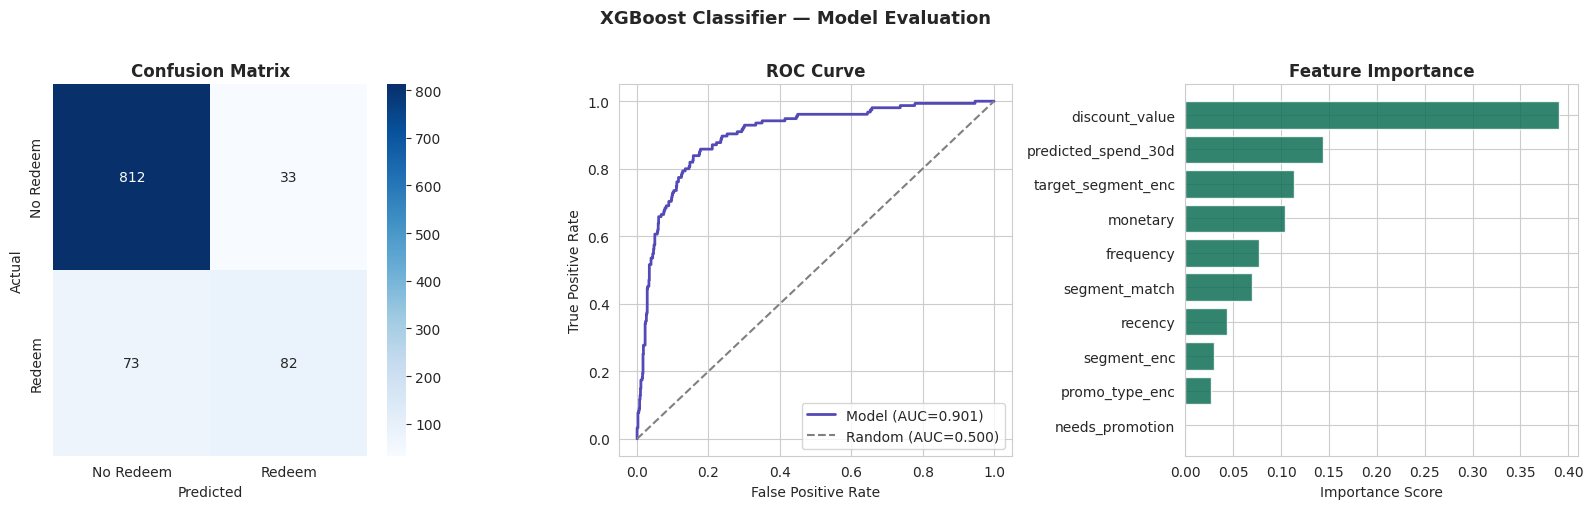


💡 Feature Importance Top 3:
   discount_value           : 0.3903
   predicted_spend_30d      : 0.1437
   target_segment_enc       : 0.1140


In [15]:
print("\n" + "─" * 50)
print("  SECTION 4 — Model Evaluation")
print("─" * 50)

print("\nClassification Report:")
print(classification_report(
    y_test, y_pred,
    target_names=['No Redeem (0)', 'Redeem (1)']
))

# ── Charts: Confusion Matrix + ROC Curve + Feature Importance ──
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Redeem', 'Redeem'],
            yticklabels=['No Redeem', 'Redeem'])
axes[0].set_title('Confusion Matrix', fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# 2. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
axes[1].plot(fpr, tpr, color=COLORS[0], linewidth=2,
             label=f'Model (AUC={auc:.3f})')
axes[1].plot([0, 1], [0, 1], '--', color='gray',
             label='Random (AUC=0.500)')
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()

# 3. Feature Importance
fi = pd.DataFrame({
    'feature'   : FEATURES,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=True)
axes[2].barh(fi['feature'], fi['importance'],
             color=COLORS[1], alpha=0.85)
axes[2].set_title('Feature Importance', fontweight='bold')
axes[2].set_xlabel('Importance Score')

plt.suptitle('XGBoost Classifier — Model Evaluation',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('diagrams/04_model_evaluation.png',
            dpi=120, bbox_inches='tight')
plt.show()

print(f"\n💡 Feature Importance Top 3:")
for _, row in fi.sort_values('importance', ascending=False).head(3).iterrows():
    print(f"   {row['feature']:<25}: {row['importance']:.4f}")


# 5. Lift Curve


──────────────────────────────────────────────────
  SECTION 5 — Lift Curve vs Random Baseline
──────────────────────────────────────────────────


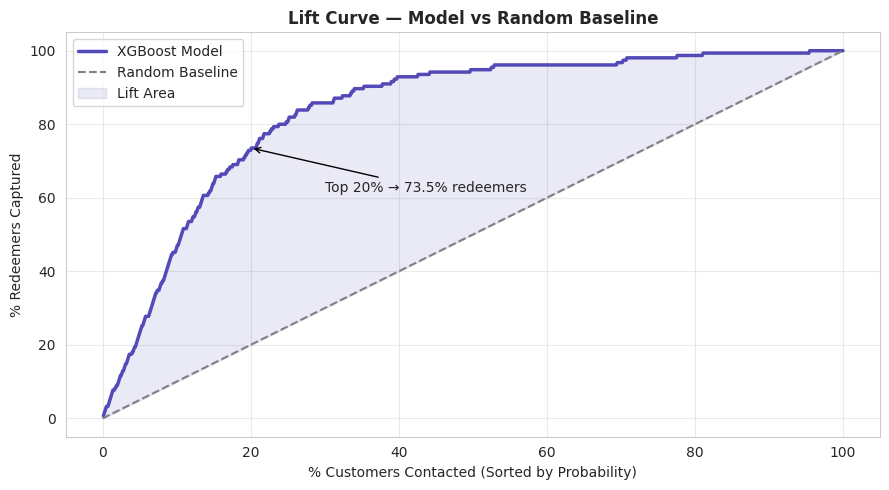


💡 Lift Curve Results:
   Top 20% → จับ redeemer ได้ 73.5%
   Random  → ได้แค่ ~20%
   Lift    = 3.68x เหนือ random


In [16]:
print("\n" + "─" * 50)
print("  SECTION 5 — Lift Curve vs Random Baseline")
print("─" * 50)

# เรียงตาม probability สูงสุด → วัดว่าจับ redeemer ได้กี่ %
lift_df = pd.DataFrame({
    'actual': y_test.values,
    'prob'  : y_pred_prob
}).sort_values('prob', ascending=False).reset_index(drop=True)

pct_contacted  = np.arange(1, len(lift_df) + 1) / len(lift_df) * 100
cumulative_hit = lift_df['actual'].cumsum() / lift_df['actual'].sum() * 100

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(pct_contacted, cumulative_hit,
        color=COLORS[0], linewidth=2.5, label='XGBoost Model')
ax.plot([0, 100], [0, 100], '--', color='gray',
        linewidth=1.5, label='Random Baseline')
ax.fill_between(
    pct_contacted, cumulative_hit,
    np.linspace(0, 100, len(pct_contacted)),
    alpha=0.12, color=COLORS[0], label='Lift Area'
)

# จุด Top 20%
idx_20 = int(len(lift_df) * 0.2)
hit_20 = cumulative_hit.iloc[idx_20]
ax.annotate(
    f'Top 20% → {hit_20:.1f}% redeemers',
    xy=(20, hit_20),
    xytext=(30, hit_20 - 12),
    arrowprops=dict(arrowstyle='->', color='black'),
    fontsize=10, fontweight='500'
)

ax.set_title('Lift Curve — Model vs Random Baseline', fontweight='bold')
ax.set_xlabel('% Customers Contacted (Sorted by Probability)')
ax.set_ylabel('% Redeemers Captured')
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('diagrams/04_lift_curve.png', dpi=120, bbox_inches='tight')
plt.show()

lift_val = hit_20 / 20
print(f"\n💡 Lift Curve Results:")
print(f"   Top 20% → จับ redeemer ได้ {hit_20:.1f}%")
print(f"   Random  → ได้แค่ ~20%")
print(f"   Lift    = {lift_val:.2f}x เหนือ random")


# 6. สร้าง Next-Best-Offer Table

In [17]:
print("\n" + "─" * 50)
print("  SECTION 6 — Next-Best-Offer Table")
print("─" * 50)

# Predict probability ทุก customer × promotion
model_df['redeem_probability'] = model.predict_proba(
    model_df[FEATURES]
)[:, 1]

# เลือก best promotion ต่อลูกค้า (probability สูงสุด)
best_promo = (
    model_df
    .sort_values('redeem_probability', ascending=False)
    .groupby('customer_id')
    .first()
    .reset_index()
)

nbo = best_promo[[
    'customer_id', 'segment', 'predicted_spend_30d',
    'promotion_id', 'discount_value', 'redeem_probability'
]].copy()

# ตัดสินใจ: ยิงโปรหรืองด
THRESHOLD = 0.50
nbo['action'] = nbo['redeem_probability'].apply(
    lambda x: '✅ Send' if x >= THRESHOLD else 'Hold (No Promo)'
)

# ลูกค้าที่งด → ไม่ระบุโปร (save margin)
nbo.loc[nbo['action'] != '✅ Send', 'promotion_id']   = '—'
nbo.loc[nbo['action'] != '✅ Send', 'discount_value'] = 0

nbo = nbo.round({'predicted_spend_30d': 2, 'redeem_probability': 4})

print("\nNext-Best-Offer Table (ตัวอย่าง 10 แถว):")
display_cols = [
    'customer_id', 'segment', 'predicted_spend_30d',
    'promotion_id', 'redeem_probability', 'action'
]
print(nbo[display_cols].head(10).to_string(index=False))

print(f"\nสรุป:")
print(nbo['action'].value_counts().to_string())


──────────────────────────────────────────────────
  SECTION 6 — Next-Best-Offer Table
──────────────────────────────────────────────────

Next-Best-Offer Table (ตัวอย่าง 10 แถว):
customer_id  segment  predicted_spend_30d promotion_id  redeem_probability          action
      C0001      New                43.10            —              0.1525 Hold (No Promo)
      C0002 Champion               479.51            —              0.4815 Hold (No Promo)
      C0003    Loyal              1018.02    P_WEEKEND              0.8032          ✅ Send
      C0004      New                 8.77    P_WELCOME              0.7316          ✅ Send
      C0005    Loyal               807.71    P_WEEKEND              0.7078          ✅ Send
      C0006      New                70.49            —              0.2925 Hold (No Promo)
      C0007 Champion               553.17    P_WEEKEND              0.5771          ✅ Send
      C0008     None                24.14            —              0.3822 Hold (No Promo)


# 7. Business Impact Summary


--------------------------------------------------
  SECTION 7 - Business Impact
--------------------------------------------------

  BUSINESS IMPACT ESTIMATE
  Send Promo : 0 users (0.0%)
  Hold       : 500 users (100.0%)
  Avg prob (Send) : nan

  Estimated Margin Saved (30d):
  ฿102,315 THB
  (From holding promos for 500 users who are likely to buy anyway)


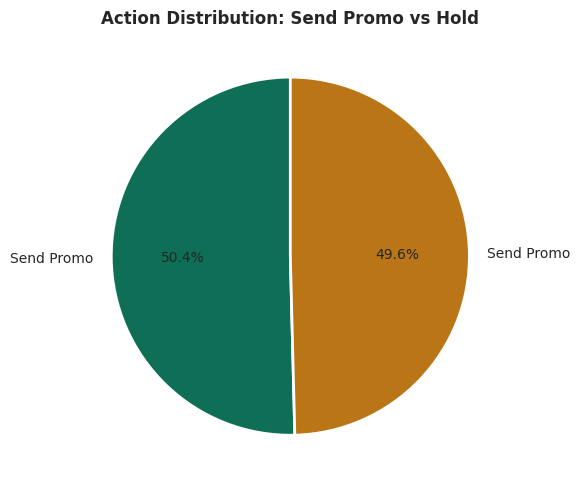

In [18]:
print("\n" + "-" * 50)
print("  SECTION 7 - Business Impact")
print("-" * 50)

fire = nbo[nbo['action'] == '✅ ยิงโปร']
hold = nbo[nbo['action'] != '✅ ยิงโปร']

# Estimated margin saved
AVG_DISCOUNT_RATE = 0.18
margin_saved = hold['predicted_spend_30d'].sum() * AVG_DISCOUNT_RATE

print("\n" + "=" * 55)
print("  BUSINESS IMPACT ESTIMATE")
print("=" * 55)
print(f"  Send Promo : {len(fire):,} users ({len(fire)/len(nbo)*100:.1f}%)")
print(f"  Hold       : {len(hold):,} users ({len(hold)/len(nbo)*100:.1f}%)")
print(f"  Avg prob (Send) : {fire['redeem_probability'].mean():.3f}")
print(f"\n  Estimated Margin Saved (30d):")
print(f"  ฿{margin_saved:,.0f} THB")
print(f"  (From holding promos for {len(hold):,} users who are likely to buy anyway)")
print("=" * 55)

# Pie Chart
fig, ax = plt.subplots(figsize=(7, 5))
counts = nbo['action'].value_counts()

# แปลง Label จากไทยเป็นอังกฤษสำหรับใส่ในกราฟ
english_labels = ['Hold (No Promo)' if 'งด' in str(x) else 'Send Promo' for x in counts.index]

ax.pie(
    counts.values,
    labels=english_labels, # ใช้ Label ภาษาอังกฤษที่แปลงแล้ว
    colors=[COLORS[1], COLORS[2]],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)

ax.set_title('Action Distribution: Send Promo vs Hold', fontweight='bold')
plt.tight_layout()
plt.savefig('diagrams/04_action_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

# Save Final Output

In [19]:
print("\n" + "─" * 50)
print("  Save Final Output")
print("─" * 50)

nbo.to_csv('data/processed/next_best_offer.csv', index=False)

print(f"\n✅ บันทึก next_best_offer.csv")
print(f"   {len(nbo):,} customers × {nbo.shape[1]} columns")
print(f"   Columns: {list(nbo.columns)}")

print("\n" + "=" * 55)
print("  🎉 PIPELINE ครบทั้ง 3 LAYERS!")
print("=" * 55)
print("  Layer 1: K-Means Clustering   → rfm_clustered.csv")
print("  Layer 2: Ridge Regression     → rfm_with_forecast.csv")
print("  Layer 3: XGBoost Classifier   → next_best_offer.csv")
print("=" * 55)


──────────────────────────────────────────────────
  Save Final Output
──────────────────────────────────────────────────

✅ บันทึก next_best_offer.csv
   500 customers × 7 columns
   Columns: ['customer_id', 'segment', 'predicted_spend_30d', 'promotion_id', 'discount_value', 'redeem_probability', 'action']

  🎉 PIPELINE ครบทั้ง 3 LAYERS!
  Layer 1: K-Means Clustering   → rfm_clustered.csv
  Layer 2: Ridge Regression     → rfm_with_forecast.csv
  Layer 3: XGBoost Classifier   → next_best_offer.csv
